# 05 — EDA: Stores and FOODS Departments

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook compares weekly demand across ten stores and the three FOODS departments. It uses **training targets only**. Validation and test targets are not loaded.

## 1. Load train-only columns

The Parquet filter is applied before loading. Only identifiers and demand-quality fields needed for this comparison are read.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as pads
from IPython.display import display

pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "m5_foods_weekly").exists():
            return candidate.resolve()
    raise FileNotFoundError("Processed FOODS data was not found. Run notebooks 01 and 02 first.")

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_weekly"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)
dataset = pads.dataset(PROCESSED_DIR, format="parquet")
train_filter = pads.field("dataset_split") == "train"
columns = ["store_id", "state_id", "dept_id", "weekly_units_sold", "has_sales_outlier"]
train_table = dataset.to_table(columns=columns, filter=train_filter)
train_table = train_table.append_column("is_zero_week", pc.equal(train_table["weekly_units_sold"], 0))

print("Train rows loaded:", f"{train_table.num_rows:,}")
print("Validation/test targets loaded: no")

Train rows loaded: 3,003,902
Validation/test targets loaded: no


## 2. Store comparison

Total demand shows business volume, while mean demand per active store-product week improves comparability. Zero-demand and outlier shares describe the shape and difficulty of forecasting each store.

In [2]:
store_statistics = train_table.group_by(["store_id", "state_id"]).aggregate([
    ("weekly_units_sold", "count"),
    ("weekly_units_sold", "sum"),
    ("weekly_units_sold", "mean"),
    ("weekly_units_sold", "max"),
    ("is_zero_week", "sum"),
    ("has_sales_outlier", "sum"),
]).to_pandas().rename(columns={
    "weekly_units_sold_count": "rows",
    "weekly_units_sold_sum": "total_units",
    "weekly_units_sold_mean": "mean_weekly_units",
    "weekly_units_sold_max": "maximum_weekly_units",
    "is_zero_week_sum": "zero_demand_weeks",
    "has_sales_outlier_sum": "outlier_weeks",
})
store_statistics["zero_demand_pct"] = 100 * store_statistics["zero_demand_weeks"] / store_statistics["rows"]
store_statistics["outlier_week_pct"] = 100 * store_statistics["outlier_weeks"] / store_statistics["rows"]
store_statistics = store_statistics.sort_values("mean_weekly_units", ascending=False).reset_index(drop=True)
display(store_statistics)

,store_id,state_id,rows,total_units,mean_weekly_units,maximum_weekly_units,zero_demand_weeks,outlier_weeks,zero_demand_pct,outlier_week_pct
0,CA_3,CA,311472,7397764,23.75,3976,42098,4795,13.52,1.54
1,CA_1,CA,311794,5289784,16.97,1697,59165,2350,18.98,0.75
2,WI_2,WI,295468,4653836,15.75,1161,64770,2691,21.92,0.91
3,TX_2,TX,314112,4937620,15.72,2076,63949,2593,20.36,0.83
4,WI_3,WI,310726,4643790,14.94,1695,71125,2900,22.89,0.93
5,CA_2,CA,253008,3394415,13.42,638,57973,841,22.91,0.33
6,TX_3,TX,306508,4089898,13.34,1215,73191,1997,23.88,0.65
7,WI_1,WI,281120,3361591,11.96,690,54578,448,19.41,0.16
8,TX_1,TX,313803,3715791,11.84,1676,70859,1508,22.58,0.48
9,CA_4,CA,305891,2768582,9.05,567,64635,258,21.13,0.08


## 3. Department comparison

FOODS_1, FOODS_2, and FOODS_3 contain different products and numbers of active records. Both total and mean demand are therefore reported.

In [3]:
department_statistics = train_table.group_by("dept_id").aggregate([
    ("weekly_units_sold", "count"),
    ("weekly_units_sold", "sum"),
    ("weekly_units_sold", "mean"),
    ("weekly_units_sold", "max"),
    ("is_zero_week", "sum"),
    ("has_sales_outlier", "sum"),
]).to_pandas().rename(columns={
    "weekly_units_sold_count": "rows",
    "weekly_units_sold_sum": "total_units",
    "weekly_units_sold_mean": "mean_weekly_units",
    "weekly_units_sold_max": "maximum_weekly_units",
    "is_zero_week_sum": "zero_demand_weeks",
    "has_sales_outlier_sum": "outlier_weeks",
})
department_statistics["zero_demand_pct"] = 100 * department_statistics["zero_demand_weeks"] / department_statistics["rows"]
department_statistics["outlier_week_pct"] = 100 * department_statistics["outlier_weeks"] / department_statistics["rows"]
department_statistics = department_statistics.sort_values("mean_weekly_units", ascending=False).reset_index(drop=True)
display(department_statistics)

,dept_id,rows,total_units,mean_weekly_units,maximum_weekly_units,zero_demand_weeks,outlier_weeks,zero_demand_pct,outlier_week_pct
0,FOODS_3,1733383,31793548,18.34,3976,326468,19014,18.83,1.10
1,FOODS_1,496308,5001801,10.08,661,113496,508,22.87,0.10
2,FOODS_2,774211,7457722,9.63,1161,182379,859,23.56,0.11


## 4. Visual comparison

The charts pair average demand with zero-demand frequency. This avoids judging a store or department from total volume alone.

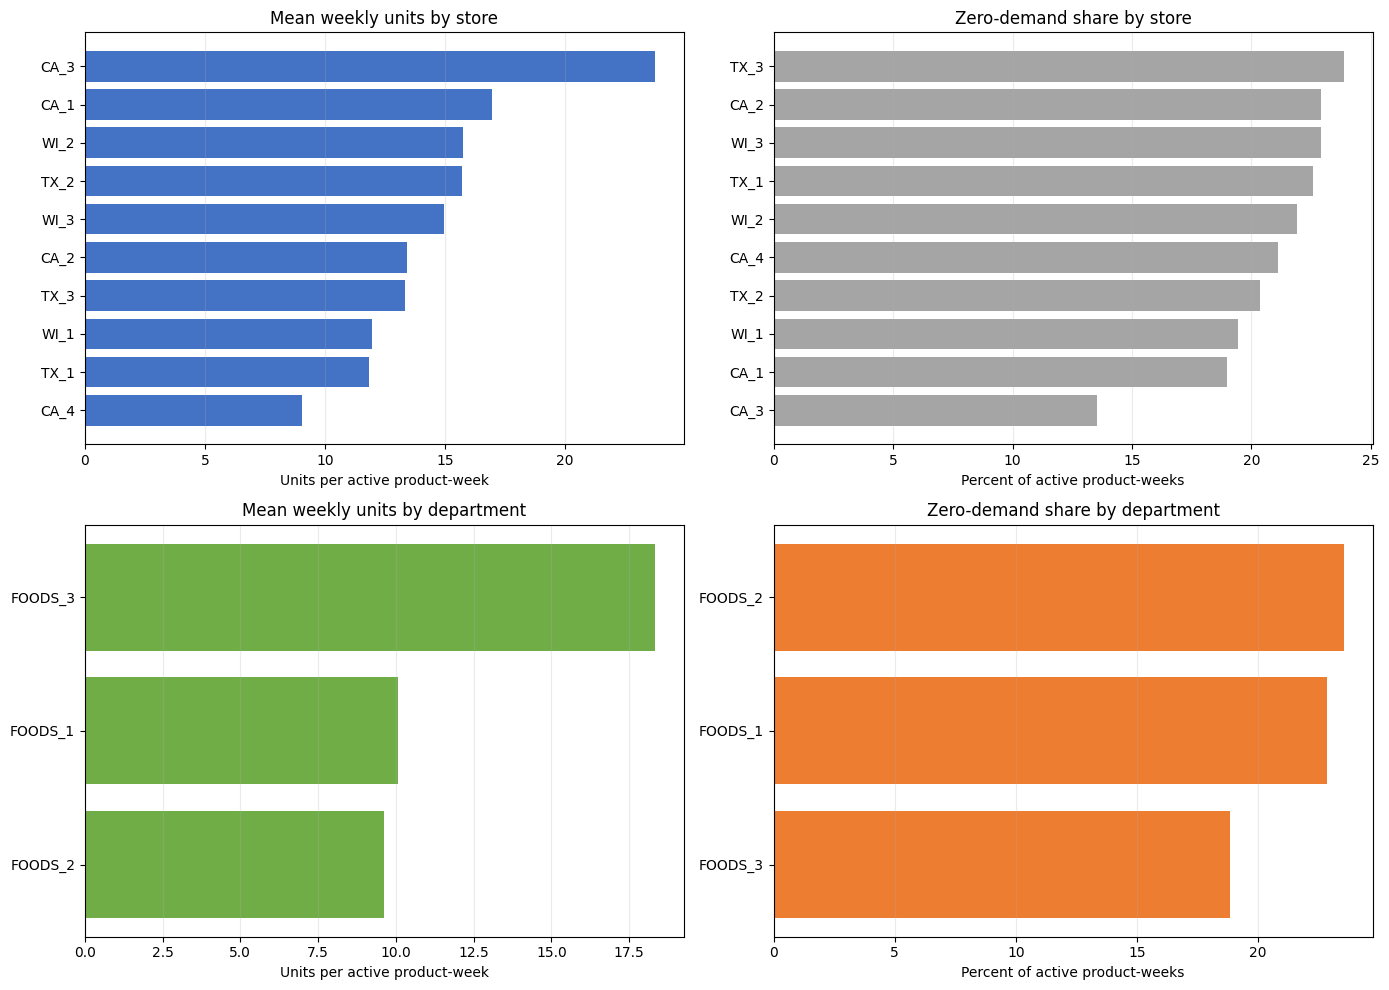

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

store_plot = store_statistics.sort_values("mean_weekly_units")
axes[0, 0].barh(store_plot["store_id"], store_plot["mean_weekly_units"], color="#4472C4")
axes[0, 0].set_title("Mean weekly units by store")
axes[0, 0].set_xlabel("Units per active product-week")

zero_store_plot = store_statistics.sort_values("zero_demand_pct")
axes[0, 1].barh(zero_store_plot["store_id"], zero_store_plot["zero_demand_pct"], color="#A5A5A5")
axes[0, 1].set_title("Zero-demand share by store")
axes[0, 1].set_xlabel("Percent of active product-weeks")

department_plot = department_statistics.sort_values("mean_weekly_units")
axes[1, 0].barh(department_plot["dept_id"], department_plot["mean_weekly_units"], color="#70AD47")
axes[1, 0].set_title("Mean weekly units by department")
axes[1, 0].set_xlabel("Units per active product-week")

department_zero_plot = department_statistics.sort_values("zero_demand_pct")
axes[1, 1].barh(department_zero_plot["dept_id"], department_zero_plot["zero_demand_pct"], color="#ED7D31")
axes[1, 1].set_title("Zero-demand share by department")
axes[1, 1].set_xlabel("Percent of active product-weeks")

for ax in axes.flat:
    ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Reproducible findings

The findings below are calculated automatically. They describe differences but do not claim why those differences exist.

In [5]:
highest_mean_store = store_statistics.loc[store_statistics["mean_weekly_units"].idxmax()]
lowest_mean_store = store_statistics.loc[store_statistics["mean_weekly_units"].idxmin()]
highest_zero_store = store_statistics.loc[store_statistics["zero_demand_pct"].idxmax()]
highest_mean_department = department_statistics.loc[department_statistics["mean_weekly_units"].idxmax()]
highest_total_department = department_statistics.loc[department_statistics["total_units"].idxmax()]
highest_zero_department = department_statistics.loc[department_statistics["zero_demand_pct"].idxmax()]

findings = pd.DataFrame([
    {"finding": "highest_mean_demand_store", "group": highest_mean_store["store_id"], "value": highest_mean_store["mean_weekly_units"]},
    {"finding": "lowest_mean_demand_store", "group": lowest_mean_store["store_id"], "value": lowest_mean_store["mean_weekly_units"]},
    {"finding": "highest_zero_share_store", "group": highest_zero_store["store_id"], "value": highest_zero_store["zero_demand_pct"]},
    {"finding": "highest_mean_demand_department", "group": highest_mean_department["dept_id"], "value": highest_mean_department["mean_weekly_units"]},
    {"finding": "highest_total_demand_department", "group": highest_total_department["dept_id"], "value": highest_total_department["total_units"]},
    {"finding": "highest_zero_share_department", "group": highest_zero_department["dept_id"], "value": highest_zero_department["zero_demand_pct"]},
])
display(findings)

,finding,group,value
0,highest_mean_demand_store,CA_3,23.75
1,lowest_mean_demand_store,CA_4,9.05
2,highest_zero_share_store,TX_3,23.88
3,highest_mean_demand_department,FOODS_3,18.34
4,highest_total_demand_department,FOODS_3,"31,793,548.00"
5,highest_zero_share_department,FOODS_2,23.56


## 6. Save and verify reports

The checks confirm ten stores, three departments, complete row accounting, and train-only execution.

In [6]:
assert train_table.num_rows == 3_003_902
assert len(store_statistics) == 10
assert len(department_statistics) == 3
assert int(store_statistics["rows"].sum()) == train_table.num_rows
assert int(department_statistics["rows"].sum()) == train_table.num_rows
assert store_statistics["zero_demand_pct"].between(0, 100).all()
assert department_statistics["zero_demand_pct"].between(0, 100).all()
assert not store_statistics.isna().any().any()
assert not department_statistics.isna().any().any()

store_statistics.to_csv(REPORT_DIR / "eda_store_statistics_train.csv", index=False)
department_statistics.to_csv(REPORT_DIR / "eda_department_statistics_train.csv", index=False)
findings.to_csv(REPORT_DIR / "eda_store_department_findings.csv", index=False)

print("EDA-3 train-only checks passed.")
print("Stores:", len(store_statistics))
print("Departments:", len(department_statistics))
print("Validation/test targets were not loaded.")

EDA-3 train-only checks passed.
Stores: 10
Departments: 3
Validation/test targets were not loaded.


## 7. Initial interpretation

Demand level, zero-demand frequency, and outlier frequency differ across stores and departments. A single overall average would hide these differences. Later evaluation should therefore report performance by store or department in addition to one overall metric.